In [ ]:
import os
import pandas as pd
from src.path import OptionPath

df_preview = pd.read_parquet(os.path.join(OptionPath.IVS, 'option_ivs_crsp_2018.parquet'))
df_preview.head()

,secid,permno,opt_date,days,delta,impl_volatility,crsp_date,crsp_monthly_return,market_cap,shrcd,size_group,is_non_micro
0,101802,76282,2018-06-29,730,50,0.294714,2018-06-01,0.06395,4413201.5,11,Large,True
1,101802,76282,2018-06-29,730,45,0.287964,2018-06-01,0.06395,4413201.5,11,Large,True
2,101802,76282,2018-06-29,730,40,0.280866,2018-06-01,0.06395,4413201.5,11,Large,True
3,101802,76282,2018-06-29,730,35,0.276304,2018-06-01,0.06395,4413201.5,11,Large,True
4,101802,76282,2018-06-29,730,30,0.273602,2018-06-01,0.06395,4413201.5,11,Large,True


In [3]:
df_preview[df_preview['is_non_micro'] == False]

,secid,permno,opt_date,days,delta,impl_volatility,crsp_date,crsp_monthly_return,market_cap,shrcd,size_group,is_non_micro
0,123075,13196,2020-01-31,30,-15,1.821963,2020-01-01,-0.132855,240567.81250,11,Micro,False
1,123075,13196,2020-01-31,30,-20,1.821093,2020-01-01,-0.132855,240567.81250,11,Micro,False
2,123075,13196,2020-01-31,30,-25,1.817533,2020-01-01,-0.132855,240567.81250,11,Micro,False
3,123075,13196,2020-01-31,30,-30,1.485179,2020-01-01,-0.132855,240567.81250,11,Micro,False
4,123075,13196,2020-01-31,30,-35,0.546099,2020-01-01,-0.132855,240567.81250,11,Micro,False
...,...,...,...,...,...,...,...,...,...,...,...,...
100515,207473,15399,2020-03-31,30,-30,1.345217,2020-03-01,-0.390879,47486.78125,11,Micro,False
100516,207473,15399,2020-03-31,30,-35,1.346507,2020-03-01,-0.390879,47486.78125,11,Micro,False
100517,207473,15399,2020-03-31,30,-40,1.347228,2020-03-01,-0.390879,47486.78125,11,Micro,False
100518,207473,15399,2020-03-31,30,-45,1.347627,2020-03-01,-0.390879,47486.78125,11,Micro,False


# Visualize

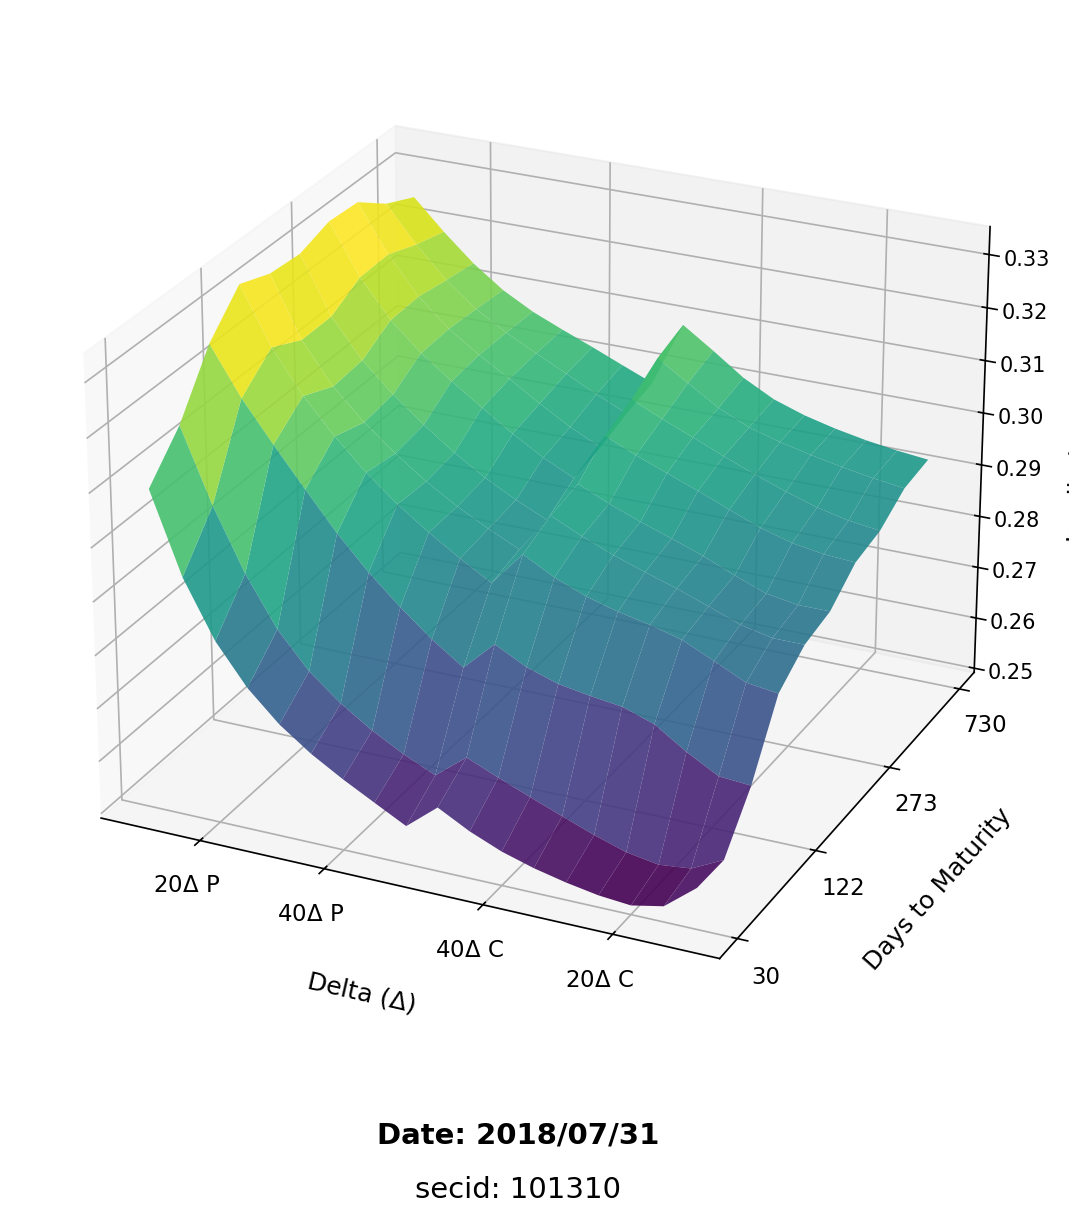

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

target_secid = 101310
target_date = '2018-07-31'

df_target = df_preview[
    (df_preview['secid'] == target_secid) &
    (df_preview['opt_date'] == target_date)
].copy()

pivot_df = df_target.pivot_table(
    index='days',
    columns='delta',
    values='impl_volatility'
)

all_deltas = pivot_df.columns.tolist()
all_days = pivot_df.index.tolist()

# X 軸排序：Put (負數，絕對值由小到大，如 -20, -30...)  Call (正數，由大到小，如 40, 30...)
put_deltas = sorted([d for d in all_deltas if d < 0], key=lambda x: abs(x)) # type: ignore
call_deltas = sorted([d for d in all_deltas if d > 0], key=lambda x: x, reverse=True) # type: ignore
x_order = put_deltas + call_deltas


y_order = sorted(all_days)
pivot_df = pivot_df.reindex(index=y_order, columns=x_order)

X_idx = np.arange(len(x_order))
Y_idx = np.arange(len(y_order))
X_grid, Y_grid = np.meshgrid(X_idx, Y_idx)
Z = pivot_df.values

fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    X_grid, Y_grid, Z,
    cmap=cm.viridis, # type: ignore
    linewidth=0,
    antialiased=True,
    alpha=0.9
)

ax.set_xlabel(r'Delta ($\Delta$)', fontsize=12, labelpad=15)
ax.set_ylabel('Days to Maturity', fontsize=12, labelpad=15)
ax.set_zlabel('Implied Volatility', fontsize=12, labelpad=10)

target_x_labels = [-20, -40, 40, 20]
x_ticks_loc = []
x_labels_text = [r'20$\Delta$ P', r'40$\Delta$ P', r'40$\Delta$ C', r'20$\Delta$ C']

for val in target_x_labels:
    if val in x_order:
        x_ticks_loc.append(x_order.index(val))

ax.set_xticks(x_ticks_loc)
ax.set_xticklabels(x_labels_text, fontsize=11)

target_y_labels = [30, 122, 273, 730]
y_ticks_loc = [y_order.index(val) for val in target_y_labels if val in y_order]

ax.set_yticks(y_ticks_loc)
ax.set_yticklabels([str(y) for y in target_y_labels if y in y_order], fontsize=11)

ax.view_init(elev=25, azim=-65)
ax.dist = 11 # type: ignore

date_str = f"Date: {target_date.replace('-', '/')}"
secid_str = f"secid: {target_secid}"

fig.text(0.5, 0.05, f"{date_str}", ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.01, secid_str, ha='center', va='center', fontsize=14)

plt.show()